# Make sure to enable gpu in colab! 

In [ ]:
!pip install optuna

In [80]:
import pandas as pd
import numpy as np
import optuna
import plotly.express as px
import xgboost as xgb

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, accuracy_score


import matplotlib.pyplot as plt


seed = 1

In [81]:
data = pd.read_csv("data.csv", delimiter=";")
data.head()

,Class,Output,Input1,Input2,Input3,Input4,Input5,Input6,Input7,Input8,...,Input391,Input392,Input393,Input394,Input395,Input396,Input397,Input398,Input399,Input400
0,0,0.800586,-0.002583,2.184037,-0.322008,1.621241,1.192444,-0.278356,-0.207366,0.735689,...,-2.140861,1.187660,0.345238,-0.844885,0.580007,-2.605781,-0.299471,0.711487,-0.753316,0.728763
1,0,2.168475,0.668637,1.373933,-0.476868,-0.724704,0.031162,-1.845921,0.784890,1.508526,...,-1.286120,-0.900044,-0.500399,-0.126421,-0.632233,-2.557419,0.056044,0.634774,-0.259835,0.106390
2,1,-1.210777,-0.681438,-0.544753,0.441346,-0.019906,-0.192135,-0.162510,-0.998777,0.686472,...,-0.391605,-0.190147,0.793746,-0.812737,-0.068228,-0.313143,2.564096,0.848355,0.180556,-1.525615
3,1,0.505678,-0.497957,0.720712,0.149120,0.019251,1.377850,0.981337,-0.846813,0.036790,...,-0.176734,-0.947351,-0.888601,1.509450,-0.501929,-0.554909,-0.104051,0.442150,-0.056644,1.447267
4,1,-10.281033,-1.178544,0.176941,1.112202,1.234189,0.999451,-0.773329,-0.811075,1.550537,...,-0.181325,0.198960,-0.697497,-0.836371,1.652071,0.974292,1.584071,-0.202352,1.362426,1.023857


In [82]:
y = data[['Class', 'Output']]
X = data.drop(columns=['Class', 'Output'])
data.describe()

,Class,Output,Input1,Input2,Input3,Input4,Input5,Input6,Input7,Input8,...,Input391,Input392,Input393,Input394,Input395,Input396,Input397,Input398,Input399,Input400
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.506500,0.106647,-0.005665,-0.016681,-0.005334,0.003488,0.002534,0.006839,-0.012273,-0.020030,...,-0.019331,0.029074,0.020895,-0.016766,-0.007556,0.010091,0.007851,0.012891,0.004650,-0.013988
std,0.500083,3.562855,0.999429,1.010284,0.991542,0.987569,0.999472,1.008721,1.005626,1.002895,...,0.994439,1.000463,0.988078,0.994856,0.983238,0.996567,0.987002,0.995252,0.999906,0.997836
min,0.000000,-12.384019,-4.040194,-3.119465,-2.978635,-3.667101,-3.466724,-3.230187,-3.686750,-2.971715,...,-4.003626,-3.415436,-3.233725,-3.292675,-3.572882,-3.416226,-2.804361,-3.384484,-3.493723,-3.369950
25%,0.000000,-2.310265,-0.652010,-0.704739,-0.649305,-0.657961,-0.662386,-0.656393,-0.670924,-0.702121,...,-0.682235,-0.637035,-0.644477,-0.687878,-0.648976,-0.720322,-0.670621,-0.644547,-0.665419,-0.690380
50%,1.000000,0.140658,0.001009,-0.058297,0.025890,0.000425,-0.037171,0.020573,0.000160,-0.006156,...,0.013317,0.027436,0.019631,-0.009518,-0.006203,0.051022,0.029848,0.042120,0.022766,-0.012325
75%,1.000000,2.435991,0.639342,0.581323,0.676253,0.648669,0.684755,0.687058,0.664702,0.668752,...,0.642293,0.732498,0.679480,0.678636,0.659516,0.777529,0.660940,0.700344,0.680525,0.674120
max,1.000000,11.676146,3.370270,5.357014,3.674250,3.872662,3.507387,3.038254,3.764414,3.466016,...,3.601507,4.390463,3.150263,3.123106,3.294423,2.962170,3.069878,3.331561,3.054563,3.129274


In [83]:
def score(model, X_, y_, scoring):
    preds = model.predict(X_)
    return scoring(y_, preds)

## Task 1. Building baseline models

I perform the split to training and testing sets separately, because I use stratification for classification splits and I don't want the 'Class' variable to have anything to do with how regression works

#### Classification


In [84]:
y_c = y['Class']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_c,
    test_size=0.1,
    stratify=y_c,
    random_state=seed
)

log_reg = LogisticRegression().fit(X_train_c, y_train_c)

train_score = score(log_reg, X_train_c, y_train_c, accuracy_score)
test_score = score(log_reg, X_test_c, y_test_c, accuracy_score)

print("Logistic Regression accuracy:")
print(" - train:", train_score)
print(" - test:", test_score)

Logistic Regression accuracy:
 - train: 0.7216666666666667
 - test: 0.49


On training data our model has ~73% accuracy. That means it's too simple for that data (or there isn't enough information in the features). 

Test accuracy is ~50% which means that the modl is basically random. So it just overfitted on the training data and not generalizing at all.

Conclusion: I should try a more complex model and possibly use some regularization techinque to avoid overfitting.

#### Regression

In [85]:
y_r = y['Output']
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_r,
    test_size=0.1,
    random_state=seed
)


lin_reg = LinearRegression().fit(X_train_r, y_train_r)

train_score = score(lin_reg, X_train_r, y_train_r, r2_score)
test_score = score(lin_reg, X_test_r, y_test_r, r2_score)

print("Linear regression R^2 score:")
print(" - train", train_score)
print(" - test", test_score)

Linear regression R^2 score:
 - train 0.625565748320505
 - test 0.2825390845575081


Here the performance on the training data is also much bigger than on the test set. However this time model is doing better than random - a model that always predicts the mean of y would score 0 on the test set.

Conclusion: We need some regularization technique and a more complex model.

Let's make models that use the whole dataset - required for evaluation on validation.csv.

In [86]:
lin_reg = LinearRegression().fit(X, y_r)
log_reg = LogisticRegression().fit(X, y_c)

## Task 2. More advanced classification

12 points=
- 3 for using a more advanced method
- 3 for parameter optimization
- 3 for feature selection
- 3 for the result analysis
 
Using some of the classification methods you have learned in the lecture try to create an improved model that performs better than your baseline model. 

You can use more complex strategies using resampling, cross-validation and/or model selection. 

Utilize the knowledge that the class variable depends on some of the predictors, but not necessarily all. 

You can also use pre-processing of the input variables, such as dimensionality reduction. 

If your model is based on some features selected from the original data, you should provide the list of features you have selected. 

Comment on any choices you make in the process and what is the relative improvement over the baseline model.

### Solution:

I decided to use XGBoost classifier to solve this task. It's definatelly one of the best "forest" models - it can use subsampling, regularization, can be accelerated on a gpu and is a very popular model for problems with small datasets (for example on kaggle). 

I will:

1. Train a simple XGBoost classifier
2. Take feature importances from that model
3. Find optimal hyperparameters using Optuna
4. Train a model with train+validation data and evaluate results on test data
5. Train a final model on all the data

I can't use cross validation - this would be kind of a data leak. The validation data should be independant from number of features so that optuna doesn't give me biased hyperparameters.

I found in my experiments the optimal number of features so I don't test it in code. I tune the most important hyperparams of XGBoost.

In [87]:
X_train_c, X_val_c, y_train_c, y_val_c = train_test_split(
    X_train_c, y_train_c,
    test_size=0.2,
    stratify=y_train_c,
    random_state=seed
)

In [ ]:
# The parameters here don't really matter much.
# Not using early stopping - avoid data leak! 
model = xgb.XGBClassifier(
    objective='binary:logistic',
    random_state=seed,
    n_estimators=200,
    learning_rate=0.01,
    max_depth=10,
    device="cuda",
    reg_alpha=1,
    reg_lambda=0,
    seed=seed,
)
model.fit(X_train_c, y_train_c)

feature_importances = model.feature_importances_
sorted_imps = sorted(feature_importances, reverse=True)

preds = model.predict(X_val_c)
test_accuracy = accuracy_score(y_val_c, preds)
print("XGBoost Classifier Test Accuracy:", test_accuracy)

fig = px.bar(
    x=range(len(sorted_imps)),
    y=sorted_imps,
    labels={'y': 'Importance'},
    title='Feature Importances from XGBoost Classifier'
)
fig.show()

XGBoost Classifier Test Accuracy: 0.7194444444444444


We can see that XGBoost works pretty well even without any feature selection or hyperparameter tuning.

Now I will pick 20 features - I found that there are ~20 useful features in the whole dataset. After removing them the model is pretty random. I will pick 5 at a time that have the best feature importance in XGB Classifier.

In [89]:
n_features = 0

X_train_filtered = None
X_val_filtered = None
X_test_filtered = None

class_feature_names = []

while n_features < 20:
    model = xgb.XGBClassifier(
        objective='binary:logistic',
        random_state=seed,
        n_estimators=200,
        learning_rate=0.01,
        max_depth=10,
        device="cuda",
        reg_alpha=1,
        reg_lambda=0
    )
    model.fit(X_train_c, y_train_c)

    preds = model.predict(X_val_c)
    val_accuracy = accuracy_score(y_val_c, preds)
    print("Current accuracy:", val_accuracy, "with", X_train_c.shape[1], "features")


    feature_importances = model.feature_importances_
    sorted_imps = sorted(feature_importances, reverse=True)
    
    threshold = sorted_imps[4] # Top 5 features
    
    imp_features = feature_importances >= threshold
    unimp_features = feature_importances < threshold
    
    class_feature_names.extend(X_train_c.columns[imp_features].tolist())

    if X_train_filtered is None:
        X_train_filtered = X_train_c.loc[:, imp_features].values
        X_val_filtered = X_val_c.loc[:, imp_features].values
        X_test_filtered = X_test_c.loc[:, imp_features].values
    else:
        X_train_filtered = np.concatenate(
            (X_train_filtered, X_train_c.loc[:, imp_features].values), axis=1
        )
        X_val_filtered = np.concatenate(
            (X_val_filtered, X_val_c.loc[:, imp_features].values), axis=1
        )
        X_test_filtered = np.concatenate(
            (X_test_filtered, X_test_c.loc[:, imp_features].values), axis=1
        )

    X_train_c = X_train_c.loc[:,unimp_features]
    X_val_c = X_val_c.loc[:,unimp_features]
    X_test_c = X_test_c.loc[:,unimp_features]

    n_features += sum(imp_features)

print("Total number of features selected:", n_features)

Current accuracy: 0.7194444444444444 with 400 features
Current accuracy: 0.7277777777777777 with 395 features
Current accuracy: 0.6694444444444444 with 390 features
Current accuracy: 0.5472222222222223 with 385 features
Total number of features selected: 20


We can see that the model is still overifitin, but as long as the validation loss is decreasing that's ok. Also this model doesn't have to be perfect - it's just for feature selection.

Now let's find the best values. **WARINING** this cell can tak a lot of time! I recommend just looking at it. the optimal parameters found by this cell are hardcoded in the next cell.

In [12]:
def objective(trial):
    model = xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        device = "cuda",
        n_estimators=1000,
        early_stopping_rounds=50,
        verbosity=0,
        seed=seed,

        learning_rate=trial.suggest_float('learning_rate',  0.001, 0.01, log=True),
        max_depth=trial.suggest_int('max_depth', 5, 12),
        min_child_weight=trial.suggest_float('min_child_weight', 0, 1),
        gamma=trial.suggest_float('gamma', 0.001, 2),
        subsample=trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bylevel=trial.suggest_float('colsample_bylevel', 0.3, 1.0),
        colsample_bynode=trial.suggest_float('colsample_bynode', 0.3, 1.0),
        reg_lambda=trial.suggest_float('reg_lambda', 0, 2), # using L2
        
    )

    model.fit(
        X_train_filtered, 
        y_train_c,
        eval_set=[(X_val_filtered, y_val_c)],
        verbose=False
    )

    best_it = model.get_booster().best_iteration
    trial.set_user_attr("best_iteration", best_it)

    return model.best_score



study = optuna.create_study(
    study_name="xgboost classification", 
    direction='minimize' # I'm minimizing logloss - accuracy is much more discrete
)
study.optimize(objective, n_trials=100, n_jobs=6)

print("Best parameters:", study.best_params)
print("Best eval logloss:", study.best_value)

[I 2025-06-03 02:07:52,646] A new study created in memory with name: xgboost classification
[I 2025-06-03 02:08:04,884] Trial 0 finished with value: 0.4758979889460736 and parameters: {'learning_rate': 0.005426875367669747, 'max_depth': 7, 'min_child_weight': 0.7102485941630278, 'gamma': 1.9194514243566698, 'subsample': 0.8666050271809089, 'colsample_bylevel': 0.32638603216006573, 'colsample_bynode': 0.6368936406568089, 'reg_lambda': 0.9164648053987046}. Best is trial 0 with value: 0.4758979889460736.
[I 2025-06-03 02:08:08,430] Trial 2 finished with value: 0.45623674313020374 and parameters: {'learning_rate': 0.0035885808083154377, 'max_depth': 6, 'min_child_weight': 0.38519675537248477, 'gamma': 0.6639684180881699, 'subsample': 0.9572666301433367, 'colsample_bylevel': 0.5527360561536774, 'colsample_bynode': 0.9722336158633902, 'reg_lambda': 0.09851642050461917}. Best is trial 2 with value: 0.45623674313020374.
[I 2025-06-03 02:08:09,884] Trial 5 finished with value: 0.569249863508674

Best parameters: {'learning_rate': 0.005765070796520263, 'max_depth': 8, 'min_child_weight': 0.12041352946983438, 'gamma': 0.2608462468895755, 'subsample': 0.7512148435830452, 'colsample_bylevel': 0.7315230642743964, 'colsample_bynode': 0.5962940064969813, 'reg_lambda': 0.3482046132757157}
Best eval logloss: 0.4005937725564258


Ok, so now let's train a model with optimal hyperparameters on both training and validation data.

If you want to see that Optune works please uncomment the redefinition of params.

In [90]:
params = {
    'learning_rate': 0.0057, 
    'max_depth': 8, 
    'min_child_weight': 0.1204, 
    'gamma': 0.2608, 
    'subsample': 0.7512, 
    'colsample_bylevel': 0.7315, 
    'colsample_bynode': 0.5962, 
    'reg_lambda': 0.34820
}
n_estimators = 942


# UNCOMMENT THESE 2 LINES TO USE THE BEST PARAMETERS FROM OPTUNA:
# params = study.best_params
# n_estimators = study.best_trial.user_attrs['best_iteration']
# print("Best number of estimators:", n_estimators)


# I increse the dataset so I also increse a bit the number of estimators
n_estimators = int(n_estimators  * 1.2)

X_sum = np.concatenate((X_train_filtered, X_val_filtered), axis=0)
y_sum = np.concatenate((y_train_c, y_val_c), axis=0)

model = xgb.XGBClassifier(
    **params,
    n_estimators=int(n_estimators),
    objective='binary:logistic',
    device='cuda',
    sampling_method='gradient_based',
    seed=seed 
)
model.fit(X_sum, y_sum)

train_accuracy = accuracy_score(y_sum, model.predict(X_sum))
test_accuracy = accuracy_score(y_test_c, model.predict(X_test_filtered))

print("Final XGBoost Classifier Train Accuracy:", train_accuracy)
print("Final XGBoost Classifier Test Accuracy:", test_accuracy)

Final XGBoost Classifier Train Accuracy: 0.9988888888888889
Final XGBoost Classifier Test Accuracy: 0.81


We can see that accuracy is greater than 0.8! It's still overfitted but that's unavoidable on such small dataset if we want to have a good model.

And for the end - let's train a model on the whole dataset (for evaluation on 'validation.csv'). It will probably have a little better results because we increse size of the dataset.

In [ ]:
X_c = np.concatenate([X_sum, X_test_filtered], axis=0)
y_c = np.concatenate([y_sum, y_test_c], axis=0)

final_classifier = xgb.XGBClassifier(
    **params,
    n_estimators=n_estimators,
    objective='binary:logistic',
    device='cuda',
    sampling_method='gradient_based',
    seed=seed
)
final_classifier.fit(X_c, y_c)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=0.7315, colsample_bynode=0.5962,
              colsample_bytree=None, device='cuda', early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=0.2608, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.0057, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
              max_leaves=None, min_child_weight=0.1204, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=1356,
              n_jobs=None, num_parallel_tree=None, ...)

## Task 3. More advanced Regression 
12 points: 
- 3 for using a more advanced method
- 3 for parameter optimization
- 3 for feature selection
- 3 for the result analysis
Using one of the approaches to model selection in classification that you have learned in the lecture, try to create an improved model that performs better than your baseline regression model. 

You can use more complex strategies using resampling, cross-validation and/or model selection. Utilize the knowledge that the output variable depends on some of the predictors, but not necessarily all of them. 

You can also use pre-processing of the input variables, such as dimensionality reduction. 

If your model is based on some features selected from the original data, you should provide the list of features you have selected. 


Comment on any choices you make in the process and what is the relative improvement over the baseline model.

In [ ]:
X_train_r, X_val_r, y_train_r, y_val_r = train_test_split(
    X_train_r, y_train_r,
    test_size=0.2,
    random_state=seed
)

To see which features are important I will use lasso. It works much better in separating important and unimportant features.

In [ ]:
from sklearn.linear_model import Lasso, Ridge

lasso = Lasso(alpha=0.1).fit(X_train_r, y_train_r)
train_score = score(lasso, X_train_r, y_train_r, r2_score)
test_score = score(lasso, X_test_r, y_test_r, r2_score)
print("Lasso Regression R^2 score:")
print(" - train", train_score)
print(" - test", test_score)

Lasso Regression R^2 score:
 - train 0.5433202084752489
 - test 0.42158975926667885


We can see that using lasso helped us - increased test R2 score form ~0.3 to ~0.4. The model is also less overited on the training data. Now let's see the feature importances.

In [ ]:
feature_importances = abs(lasso.coef_)
sorted_imps = sorted(feature_importances, reverse=True)

print("Lasso found", sum(feature_importances != 0), "non-zero features")

fig = px.bar(
    x=range(len(sorted_imps)),
    y=sorted_imps,
    labels={'y': 'Importance'},
    title='Feature Weights from Lasso Regression'
)
fig.show()

Lasso found 56 non-zero features


Ok, so now let's select these features! 

In [ ]:
imp_features = feature_importances > 0

X_train_filtered = X_train_r.iloc[:, imp_features].values
X_val_filtered = X_val_r.iloc[:, imp_features].values
X_test_filtered = X_test_r.iloc[:, imp_features].values

Let's try to see their relation to 'Output'.

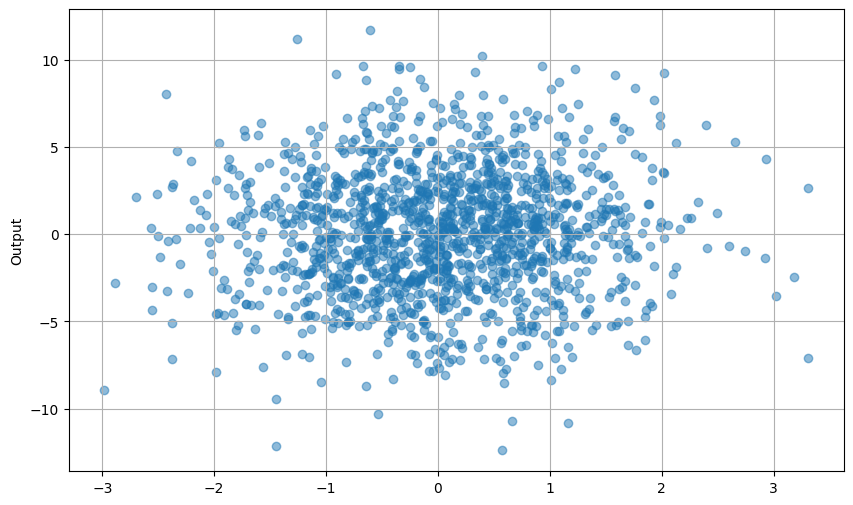

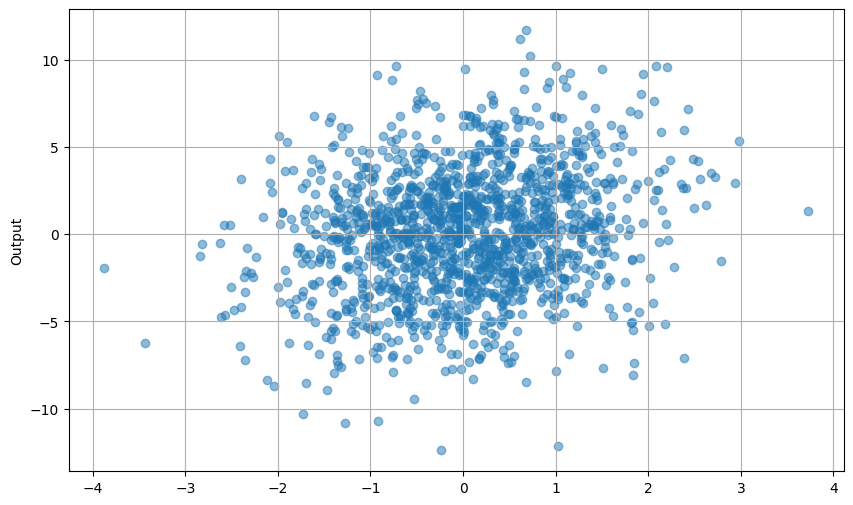

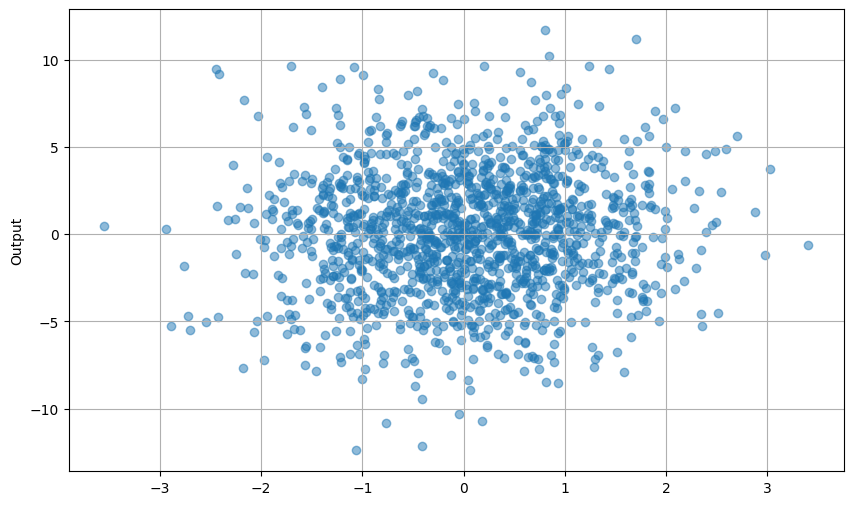

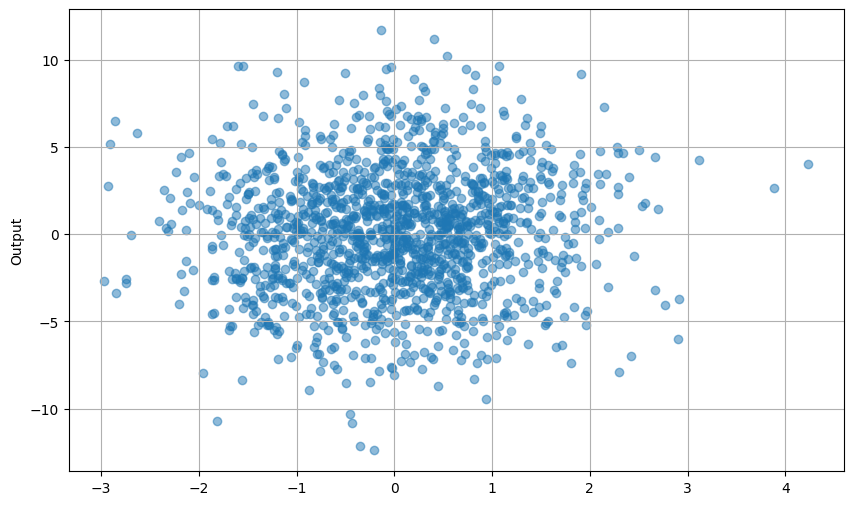

In [ ]:
# plot the featur0 vs output relationship
def plot_feature_vs_output(x, y):
    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, alpha=0.5)
    plt.ylabel('Output')
    plt.grid(True)
    plt.show()

for i in range(4):
    plot_feature_vs_output(X_train_filtered[:, i], y_train_r)

We can see that there is a bit of linear pattern with a lot of nosie. 

I decided to use AdaBoost regression. This is an ensemble boosting mathod that allows me to choose my own estimator. I chose Ridge. I use optuna to find hyperparams. This time it works fast.

In [105]:
from sklearn.ensemble import AdaBoostRegressor

def objective(trial):
    model = AdaBoostRegressor(
        estimator=Ridge(
            alpha=trial.suggest_float('ridge_alpha', 0.01, 2.0, log=True),
            random_state=seed
        ),
        loss=trial.suggest_categorical('loss', ['linear', 'square', 'exponential']),
        learning_rate=trial.suggest_float('learning_rate', 0.001, 0.1, log=True),
        n_estimators=trial.suggest_int('n_estimators', 50, 500),
        random_state=seed
    )

    n_features = trial.suggest_int('n_features', 10, 20)
    min_imp = sorted_imps[n_features - 1]
    
    selected_features = feature_importances >= min_imp
    X_train_obj = X_train_r.iloc[:, selected_features]
    X_val_obj = X_val_r.iloc[:, selected_features] 

    model.fit(X_train_obj, y_train_r)
    return score(model, X_val_obj, y_val_r, r2_score)

study = optuna.create_study(
    study_name="Adaboost with Ridge regression", 
    direction='maximize'
)
study.optimize(objective, n_trials=200, n_jobs=6)
print("Best parameters:", study.best_params)
print("Best eval R^2 score:", study.best_value)

[I 2025-06-03 03:12:28,160] A new study created in memory with name: Adaboost with Ridge regression
[I 2025-06-03 03:12:28,748] Trial 2 finished with value: 0.46333845292836995 and parameters: {'ridge_alpha': 0.025901128118862353, 'loss': 'linear', 'learning_rate': 0.08093533352904454, 'n_estimators': 268, 'n_features': 19}. Best is trial 2 with value: 0.46333845292836995.
[I 2025-06-03 03:12:28,871] Trial 3 finished with value: 0.48175636006987554 and parameters: {'ridge_alpha': 0.03733533568548191, 'loss': 'exponential', 'learning_rate': 0.0026181826888002145, 'n_estimators': 139, 'n_features': 14}. Best is trial 3 with value: 0.48175636006987554.
[I 2025-06-03 03:12:29,071] Trial 0 finished with value: 0.4652618125725314 and parameters: {'ridge_alpha': 0.23407092162080406, 'loss': 'linear', 'learning_rate': 0.004526333473324894, 'n_estimators': 200, 'n_features': 12}. Best is trial 3 with value: 0.48175636006987554.
[I 2025-06-03 03:12:29,363] Trial 1 finished with value: 0.47719340

Best parameters: {'ridge_alpha': 0.05401032701984561, 'loss': 'exponential', 'learning_rate': 0.008213337810730479, 'n_estimators': 148, 'n_features': 14}
Best eval R^2 score: 0.4824745152496285


It seems to work a bit better than lasso. Let's chek by training on train + validation.

In [106]:
best_params = study.best_params
n_features = best_params.pop('n_features')

selected_features = feature_importances >= sorted_imps[n_features - 1]
reg_feature_names = X_train_r.columns[selected_features].tolist()

X_train_filtered = X_train_r.iloc[:, selected_features]
X_val_filtered = X_val_r.iloc[:, selected_features]
X_test_filtered = X_test_r.iloc[:, selected_features]

X_sum = pd.concat([X_train_filtered, X_val_filtered], axis=0)
y_sum = pd.concat([y_train_r, y_val_r], axis=0)


alpha = best_params.pop('ridge_alpha')
model = AdaBoostRegressor(
    estimator=Ridge(
        alpha=alpha,
        random_state=seed
    ),
    **best_params,
    random_state=seed
)
    

model.fit(X_sum, y_sum)
train_score = score(model, X_sum, y_sum, r2_score)
test_score = score(model, X_test_filtered, y_test_r, r2_score)
print("Final Bagging Regressor Train R^2 score:", train_score)
print("Final Bagging Regressor Test R^2 score:", test_score)

Final Bagging Regressor Train R^2 score: 0.528700800965042
Final Bagging Regressor Test R^2 score: 0.4514228091172502


Ok, we increased our results but not by much. It's not >0.5 on test data, but this can be just unlucky seed (I had to keep test data small to get as much training data as possible). I think it is possible that on validation.csv it will do the 0.5.

It is however also possible that the model architecture I picked is just not sufficient to have better results.

In [107]:
X_r = pd.concat([X_sum, X_test_filtered], axis=0)
y_r = pd.concat([y_sum, y_test_r], axis=0)
final_regressor = AdaBoostRegressor(
    estimator=Ridge(
        alpha=alpha,
        random_state=seed
    ),
    n_estimators=best_params['n_estimators'],
    learning_rate=best_params['learning_rate'],
    random_state=seed
)
final_regressor.fit(X_r, y_r)

AdaBoostRegressor(estimator=Ridge(alpha=0.05401032701984561, random_state=1),
                  learning_rate=0.008213337810730479, n_estimators=148,
                  random_state=1)

Now let's make the validation function

In [ ]:
def validate(file="validation_data.csv"):
    val_data = pd.read_csv(file, delimiter=";")
    val_y_c = val_data['Class']
    val_y_r = val_data['Output']
    
    val_X = val_data.drop(columns=['Class', 'Output'])

    val_X_c = val_X[class_feature_names]
    val_X_r = val_X[reg_feature_names]


    print("Classification validation accuracy:")
    print(" - Logistic Regression:", accuracy_score(val_y_c, log_reg.predict(val_X)))
    print(" - XGBoost:", accuracy_score(val_y_c, final_classifier.predict(val_X_c)))

    print("Regression validation R^2 score:")
    print(" - Linear Regression:", r2_score(val_y_r, lin_reg.predict(val_X)))
    print(" - AdaBoost with Ridge:", r2_score(val_y_r, final_regressor.predict(val_X_r)))

validate()